In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [165]:
df = pd.read_csv('data/datos.csv')

Conocer las distrbuciones de nuestras variables


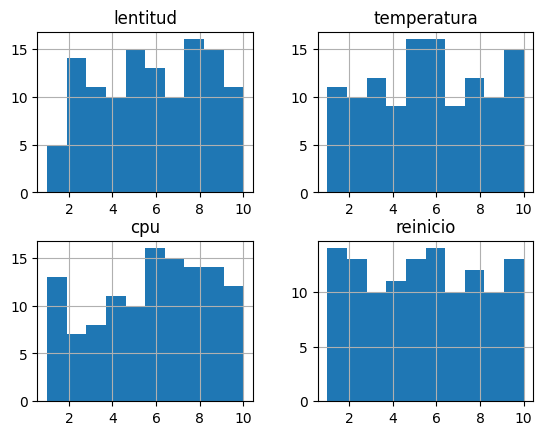

In [166]:
print('Conocer las distrbuciones de nuestras variables')
df.hist()
plt.show()

`ctrl.Antecedent(np.arange(0, 11, 1), 'nombre')`: Define las variables de entrada del sistema difuso (también llamadas antecedentes). El rango `np.arange(0, 11, 1)` indica que estas variables toman valores entre 0 y 10.

`lentitud`, `cpu`, `temperatura`, y `reinicios` son las variables que representan las condiciones del sistema.
target es la variable de salida (consecuente), que representará el estado del sistema ("estable", "moderado", "crítico").

In [167]:
# Definimos los universos para cada variable.
lentitud = ctrl.Antecedent(np.arange(0, 11, 1), 'lentitud')
cpu = ctrl.Antecedent(np.arange(0, 11, 1), 'cpu')
temperatura = ctrl.Antecedent(np.arange(0, 11, 1), 'temperatura')
reinicios = ctrl.Antecedent(np.arange(0, 11, 1), 'reinicios')

# Definimos la variable de salida (Target).
target = ctrl.Consequent(np.arange(0, 11, 1), 'target')

`fuzz.trimf(lentitud.universe, [0, 0, 5])`: Asigna funciones de `pertenencia triangulares` a las variables.

- `lentitud['baja']`: Define que la lentitud será baja cuando esté entre 0 y 5 (mayor pertenencia en el valor 0).
- `lentitud['media']`: Define que la lentitud será media cuando esté entre 0 y 10, con mayor pertenencia en 5.
- `lentitud['alta']`: Define lentitud alta en el rango de 5 a 10.

Este patrón se repite para todas las variables, adaptando los rangos para `cpu`, `temperatura`, `reinicios` y `target`.

In [168]:
# Autoasignamos funciones de pertenencia (Triangular).
lentitud['baja'] = fuzz.trimf(lentitud.universe, [0, 0, 5])
lentitud['media'] = fuzz.trimf(lentitud.universe, [0, 5, 10])
lentitud['alta'] = fuzz.trimf(lentitud.universe, [5, 10, 10])

cpu['bajo'] = fuzz.trimf(cpu.universe, [0, 0, 5])
cpu['medio'] = fuzz.trimf(cpu.universe, [0, 5, 10])
cpu['alto'] = fuzz.trimf(cpu.universe, [5, 10, 10])

temperatura['fria'] = fuzz.trimf(temperatura.universe, [0, 0, 5])
temperatura['normal'] = fuzz.trimf(temperatura.universe, [0, 5, 10])
temperatura['caliente'] = fuzz.trimf(temperatura.universe, [5, 10, 10])

reinicios['ninguno'] = fuzz.trimf(reinicios.universe, [0, 0, 5])
reinicios['pocos'] = fuzz.trimf(reinicios.universe, [0, 5, 10])
reinicios['muchos'] = fuzz.trimf(reinicios.universe, [5, 10, 10])

# Definimos las reglas para el Target.
target['estable'] = fuzz.trimf(target.universe, [0, 0, 5])
target['moderado'] = fuzz.trimf(target.universe, [0, 5, 10])
target['critico'] = fuzz.trimf(target.universe, [5, 10, 10])

`ctrl.Rule()`: Define reglas de inferencia difusa que conectan las variables de entrada con la variable de salida. Cada regla toma en cuenta combinaciones de estados de las variables.
- **rule1**: Si lentitud es alta, cpu es alto, temperatura es caliente, y reinicios son muchos, entonces el target es crítico.
- **rule2**: Si los valores están en niveles medios, el sistema es moderado.
- **rule3**: Si los valores están bajos, el sistema es estable.

In [169]:
# Reglas difusas.
rule1 = ctrl.Rule(lentitud['alta'] & cpu['alto'] & temperatura['caliente'] & reinicios['muchos'], target['critico'])
rule2 = ctrl.Rule(lentitud['media'] & cpu['medio'] & temperatura['normal'] & reinicios['pocos'], target['moderado'])
rule3 = ctrl.Rule(lentitud['baja'] & cpu['bajo'] & temperatura['fria'] & reinicios['ninguno'], target['estable'])

In [170]:
# Creamos el sistema de control.
control_system = ctrl.ControlSystem([rule1, rule2, rule3])
simulation = ctrl.ControlSystemSimulation(control_system)

In [171]:
# Probamos con algunos valores.
simulation.input['lentitud'] = 7  # Ejemplo de entrada difusa
simulation.input['cpu'] = 8
simulation.input['temperatura'] = 9
simulation.input['reinicios'] = 2

# Calculamos el resultado.
simulation.compute()

# Mostramos el resultado.
print(simulation.output['target'])

5.000000000000001


/home/martin/miniconda3/envs/universidad/lib/python3.10/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


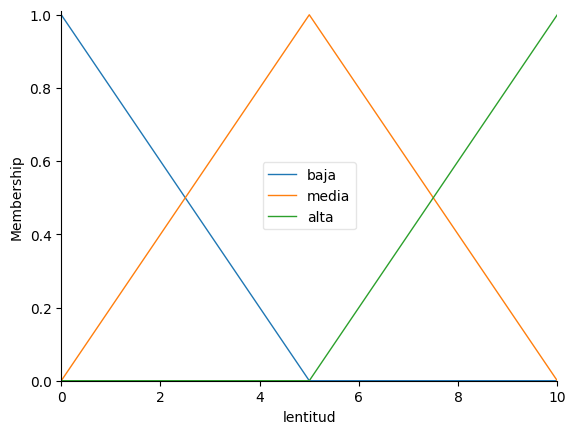

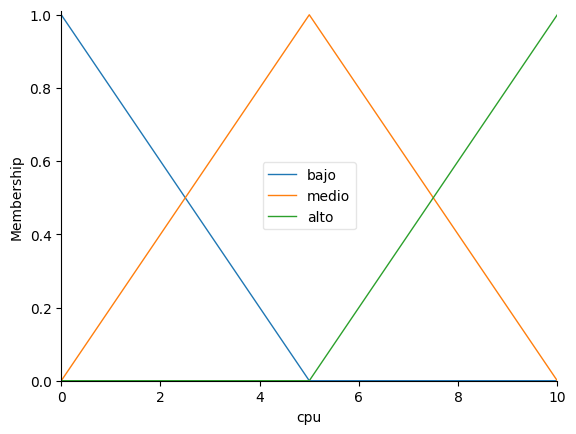

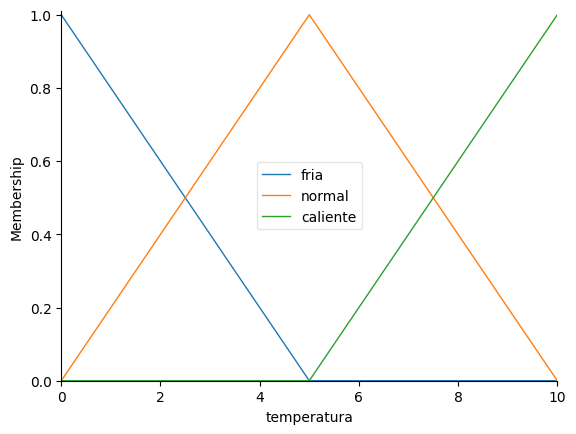

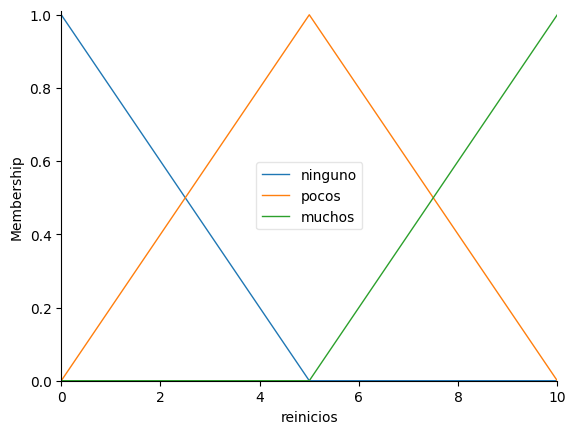

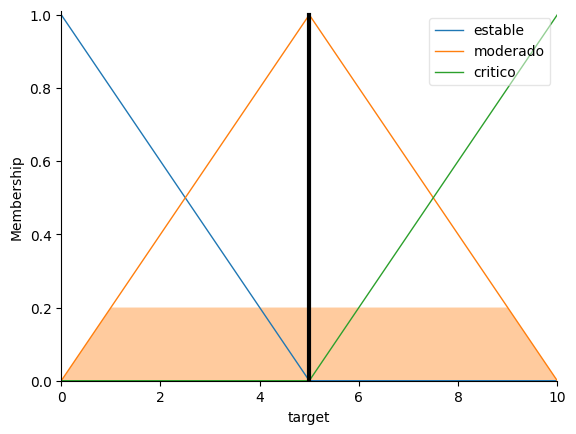

In [172]:
# Graficamos las funciones de pertenencia para lentitud, cpu, temperatura y reinicios.
lentitud.view()
cpu.view()
temperatura.view()
reinicios.view()

# Graficamos la salida (Target)
target.view(sim= simulation)

plt.show()

In [185]:
# Crear una columna target apartir del sistema de control.
df['target'] = None

for i in range(len(df)):
    simulation.input['lentitud'] = df['lentitud'][i]
    simulation.input['cpu'] = df['cpu'][i]
    simulation.input['temperatura'] = df['temperatura'][i]
    simulation.input['reinicios'] = df['reinicio'][i]
    
    simulation.compute()

    try:
        df['target'][i] = simulation.output['target']
    except:
        df['target'][i] = None

/tmp/ipykernel_16193/278059414.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['target'][i] = simulation.output['target']
/tmp/ipykernel_16193/278059414.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [190]:
df['target'] = df['target'].fillna(df['target'].mean())

In [198]:
# Tomar los deciles de la variable target.
pd.qcut(df['target'], 3, labels= False).value_counts(1)

# Con esto obtenemos la variable target en 3 categorias.

target
0    0.658333
2    0.316667
1    0.025000
Name: proportion, dtype: float64

El target será definido como si es menor a 0.02 es 0 (computadora en defecto), si encuentra en 0.02 y 0.31 (computadora normal) y si encuentra en 0.31 a 0.65 (computadora optima).